# ※ 1단계 > naver open API를 활용하여 네이버지식인에서 각 500개씩 "전주여행"과 "경주여행"을 검색 (특수문자 빼기)((groubby 가능하게)csv백업)-> 
# ※ 2단계 >품사태깅 백업(csv백업), 명사만 추출 -> 빈도분석(DataFrame)(csv백업) -> 빈도 시각화(워드클라우드, Text) -> Word2Vec(csv백업)

'''
conda activate ml-dl-nlp
pip install python-dotenv

'''

# 1. 네이버 open API를 활용하여 검색 추출
- 검색어, no, title, link, description, 명사로추출df(title+' '+description)(total_text)

In [2]:
# pip install python-dotenv (환경변수를 쓰기 위한 라이브러리)
# pip install python-decouple (주피터에서는 사용 안됨)
import os
os.getcwd() # 현재 작업디렉토리

'C:\\ai_x\\source\\07_자연어처리'

In [5]:
%ls .env

 C 드라이브의 볼륨에는 이름이 없습니다.
 볼륨 일련 번호: 3664-591E

 C:\ai_x\source\07_자연어처리 디렉터리

2025-06-18  오후 05:47                58 .env
               1개 파일                  58 바이트
               0개 디렉터리  115,935,191,040 바이트 남음


In [4]:
# print(os.getenv('Client_ID'))
# print(os.getenv('Client_Secret'))

bT7ctjQcsaRNLUAu85bK
HyWavVuxdp


In [6]:
# 장고에서는 됨
from decouple import config
# print(config('Client_ID'))
# print(config('Client_Secret'))

bT7ctjQcsaRNLUAu85bK


In [3]:
# 환경변수를 가져오기
from dotenv import load_dotenv
import os
load_dotenv() #dotenv_path='.env' 기본값 생략가능

True

# 1. naver open API를 활용하여 네이버지식인에서 각 500개씩 "전주여행"과 "경주여행"을 검색 (특수문자 빼기)((groubby 가능하게)csv백업)

In [8]:
import requests
import pandas as pd
import json
import os
import re
from dotenv import load_dotenv

load_dotenv()
client_id = os.getenv('Client_ID')
client_secret = os.getenv('Client_Secret')

keywords = ['전주여행', '경주여행']
display = 100
total_count = 500

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s가-힣]', '', text)
    return text.strip()

for keyword in keywords:
    all_items = []

    for start in range(1, total_count + 1, display):
        url = f'https://openapi.naver.com/v1/search/kin.json?query={keyword}&display={display}&start={start}'
        headers = {
            'X-Naver-Client-Id': client_id,
            'X-Naver-Client-Secret': client_secret
        }
        response = requests.get(url, headers=headers)

        if response.status_code != 200:
            print(f"Error: {response.status_code} - {response.text}")
            continue

            
        items = response.json().get('items', [])
        
        for item in items:
            all_items.append([
                clean_text(item.get('title', '')),
                item.get('link', ''),
                clean_text(item.get('description', ''))
            ])

    df = pd.DataFrame(all_items, columns=['title', 'link', 'description'])
    df.to_csv(f'{keyword}_네이버지식인.csv', index=False, encoding='utf-8-sig')
    print(f"{keyword}, {len(df)}건 저장완료")

전주여행, 500건 저장완료
경주여행, 500건 저장완료


# 2. 품사태깅 백업(csv백업), 명사만 추출

In [10]:
# 전주여행
import pandas as pd
from mecab import MeCab

mecab = MeCab()

df = pd.read_csv('전주여행_네이버지식인.csv')

def extract_nouns(text):
    if pd.isna(text):
        return []
    return mecab.nouns(text)

df['title_nouns'] = df['title'].apply(extract_nouns)
df['desc_nouns'] = df['description'].apply(extract_nouns)

df['all_nouns'] = df['title_nouns'] + df['desc_nouns']

df.to_csv('전주여행_명사mecab.csv', index=False, encoding='utf-8-sig')
print("전주여행_명사mecab.csv, 저장완료")

전주여행_명사mecab.csv, 저장완료


In [11]:
# 경주여행
import pandas as pd
from mecab import MeCab

mecab = MeCab()

df = pd.read_csv('경주여행_네이버지식인.csv')

def extract_nouns(text):
    if pd.isna(text):
        return []
    return mecab.nouns(text)

df['title_nouns'] = df['title'].apply(extract_nouns)
df['desc_nouns'] = df['description'].apply(extract_nouns)

df['all_nouns'] = df['title_nouns'] + df['desc_nouns']

df.to_csv('경주여행_명사mecab.csv', index=False, encoding='utf-8-sig')
print("경주여행_명사mecab.csv, 저장완료")

경주여행_명사mecab.csv, 저장완료


# 3. 빈도분석(DataFrame)(csv백업)

In [18]:
# 전주여행
import pandas as pd
from collections import Counter

df = pd.read_csv('전주여행_명사mecab.csv')

import ast
df['all_nouns'] = df['all_nouns'].apply(ast.literal_eval)

all_nouns_flat = [noun for nouns in df['all_nouns'] for noun in nouns]

noun_freq = Counter(all_nouns_flat)

freq_df = pd.DataFrame(noun_freq.items(), columns=['word', 'count'])
freq_df = freq_df.sort_values(by='count', ascending=False).reset_index(drop=True)

freq_df.to_csv('전주여행_명사빈도분석.csv', index=False, encoding='utf-8-sig')
print("전주여행_명사빈도분석.csv, 저장완료")

전주여행_명사빈도분석.csv, 저장완료


In [19]:
# 경주여행
import pandas as pd
from collections import Counter

df = pd.read_csv('경주여행_명사mecab.csv')

import ast
df['all_nouns'] = df['all_nouns'].apply(ast.literal_eval)

all_nouns_flat = [noun for nouns in df['all_nouns'] for noun in nouns]

noun_freq = Counter(all_nouns_flat)

freq_df = pd.DataFrame(noun_freq.items(), columns=['word', 'count'])
freq_df = freq_df.sort_values(by='count', ascending=False).reset_index(drop=True)

freq_df.to_csv('경주여행_명사빈도분석.csv', index=False, encoding='utf-8-sig')
print("경주여행_명사빈도분석.csv, 저장완료")

경주여행_명사빈도분석.csv, 저장완료


# 4. 빈도 시각화(워드클라우드, Text)

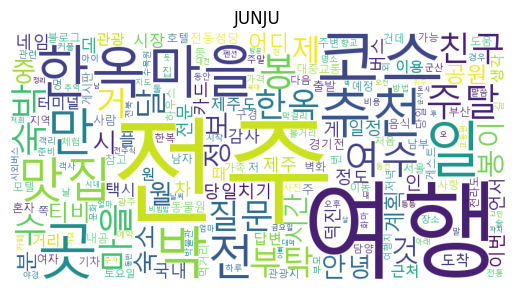

In [20]:
# 전주여행
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

df = pd.read_csv('전주여행_명사빈도분석.csv')

word_freq = dict(zip(df['word'], df['count']))

wordcloud = WordCloud(
    font_path='C:/Windows/Fonts/malgun.ttf',
    width=800,
    height=400,
    background_color='white'
).generate_from_frequencies(word_freq)

plt.figure(figsize=(8, 3))
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout()
plt.show()

wordcloud.to_file("전주여행워드클라우드.png")
print("전주여행워드클라우드.png, 저장완료")

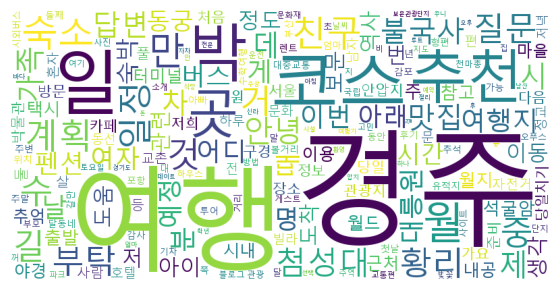

경주여행워드클라우드.png, 저장완료


In [22]:
# 경주여행
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

df = pd.read_csv('경주여행_명사빈도분석.csv')

word_freq = dict(zip(df['word'], df['count']))

wordcloud = WordCloud(
    font_path='C:/Windows/Fonts/malgun.ttf',
    width=800,
    height=400,
    background_color='white'
).generate_from_frequencies(word_freq)

plt.figure(figsize=(8, 3))
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout()
plt.show()

wordcloud.to_file("경주여행워드클라우드.png")
print("경주여행워드클라우드.png, 저장완료")

In [23]:
# 경주 상위 10개 명사
print("경주 상위 10개 명사 :")
print(df.head(10).to_string(index=False))

경주 상위 10개 명사 :
word  count
  경주   1937
  여행   1568
   일    389
  코스    370
   박    298
  추천    261
   곳    207
   월    143
   만    107
  숙소     98


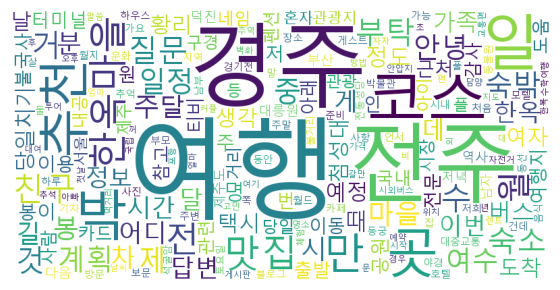

전주여행_경주여행_워드클라우드.png, 저장완료


In [28]:
# 전주여행 + 경주여행
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

df_j = pd.read_csv('전주여행_명사빈도분석.csv')
df_g = pd.read_csv('경주여행_명사빈도분석.csv')

df_all = pd.concat([df_j, df_g])
df_all = df_all.groupby('word', as_index=False)['count'].sum()
df_all = df_all.sort_values(by='count', ascending=False)
df_all.to_csv('경주여행_전주여행_명사빈도분석.csv', index=False, encoding='utf-8-sig')

word_freq = dict(zip(df_all['word'], df_all['count']))

wordcloud = WordCloud(
    font_path='C:/Windows/Fonts/malgun.ttf',
    width=800,
    height=400,
    background_color='white'
).generate_from_frequencies(word_freq)

plt.figure(figsize=(8, 3))
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout()
plt.show()

wordcloud.to_file("전주여행_경주여행_워드클라우드.png")
print("전주여행_경주여행_워드클라우드.png, 저장완료")

In [26]:
# 전주여행 + 경주여행 상위 10개 명사
print("전주여행 + 경주여행 상위 10개 명사:")
print(df_all.sort_values(by='count', ascending=False).head(10).to_string(index=False))

전주여행 + 경주여행 상위 10개 명사:
word  count
  여행   2997
  경주   1944
  전주   1764
  코스    723
   일    703
   박    555
   곳    518
  추천    495
   만    320
한옥마을    264


# 5. Word2Vec(csv백업)

In [32]:
# 전주여행 + 경주여행(mecab) word2vec(vector)
import pandas as pd
from gensim.models import Word2Vec
import ast

df1 = pd.read_csv('전주여행_명사mecab.csv')
df2 = pd.read_csv('경주여행_명사mecab.csv')

df1['all_nouns'] = df1['all_nouns'].apply(ast.literal_eval)
df2['all_nouns'] = df2['all_nouns'].apply(ast.literal_eval)

df_all = pd.concat([df1, df2])

sentences = df_all['all_nouns'].tolist()

model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

words = list(model.wv.index_to_key)
vectors = [model.wv[word] for word in words]
vec_df = pd.DataFrame(vectors, index=words)
vec_df.index.name = 'word'
vec_df.to_csv('전주여행_경주여행_word2vec.csv', encoding='utf-8-sig')
print("전주여행_경주여행_word2vec.csv, 저장 완료")

전주여행_경주여행_word2vec.csv, 저장 완료


In [35]:
# 유사한 단어 출력
print("입력된 단어와 유사한 단어 10개를 출력합니다.")
key = input()
if key in model.wv:
    print("{}와 유사한 단어:".format(key))
    print(model.wv.most_similar(key, topn=10))
else:
    print("{key} 단어가 훈련 데이터에 없음".format(key))

입력된 단어와 유사한 단어 10개를 출력합니다.
경주
경주와 유사한 단어:
[('중', 0.9686619639396667), ('월', 0.9515332579612732), ('아이', 0.9462755918502808), ('계획', 0.9436206817626953), ('여행지', 0.9425299167633057), ('주', 0.94073486328125), ('일정', 0.937232255935669), ('여자', 0.9266166090965271), ('펜션', 0.9257301092147827), ('형편', 0.9247479438781738)]
